In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

In [2]:
df = pd.read_csv('upi_fraud_transactions_features.csv')
df.shape

(100000, 29)

In [3]:
df.head()

,transaction_id,timestamp,amount,sender_age,receiver_type,transaction_type,device_id,location,hour,account_age_days,...,late_night,high_amount_flag,velocity_flag,location_anomaly_flag,device_risk,receiver_risk,failed_attempt_risk,late_night_flag,account_age_risk,risk_signal_count
0,TXN0000001,2026-01-01 00:00:00,1152.81,35.0,Person,P2M,DEV06256,Chennai,0,3296,...,1,0,0,0,0,0,1,1,0,2
1,TXN0000002,2026-01-01 00:05:00,300.44,42.0,Person,P2P,DEV03626,Chennai,0,2700,...,1,0,0,0,0,0,0,1,0,1
2,TXN0000003,2026-01-01 00:10:00,1800.26,31.0,Person,BillPayment,DEV02206,Bengaluru,0,3365,...,1,0,0,0,0,0,0,1,0,1
3,TXN0000004,2026-01-01 00:15:00,2177.21,69.0,Merchant,P2P,DEV00726,Pune,0,3183,...,1,0,0,0,0,0,0,1,0,1
4,TXN0000005,2026-01-01 00:20:00,120.81,40.0,Person,P2M,DEV07759,Pune,0,1533,...,1,0,0,0,0,0,0,1,0,1


In [4]:
y = df['fraud_label']
y.value_counts()

fraud_label
0    97575
1     2425
Name: count, dtype: int64

In [5]:
drop_cols = [
    'transaction_id',
    'timestamp',
    'fraud_label',
    'high_amount',
    'late_night'
]
X = df.drop(columns=drop_cols, errors='ignore')
X.shape

(100000, 24)

In [6]:
categorical_cols = [
    'receiver_type',
    'transaction_type',
    'device_id',
    'location'
]
numerical_cols = [
    col for col in X.columns
    if col not in categorical_cols
]
print("Numerical:", len(numerical_cols))
print("Categorical:", len(categorical_cols))

Numerical: 20
Categorical: 4


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [8]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("\nTrain Fraud %:",y_train.mean() * 100)
print("Test Fraud %:",y_test.mean() * 100)

Train: (80000, 24)
Test: (20000, 24)

Train Fraud %: 2.4250000000000003
Test Fraud %: 2.4250000000000003


In [9]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

In [10]:
log_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=1000
    ))
])

In [11]:
log_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [12]:
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.84      0.91     19515
           1       0.04      0.28      0.08       485

    accuracy                           0.83     20000
   macro avg       0.51      0.56      0.49     20000
weighted avg       0.96      0.83      0.89     20000



In [14]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print("ROC-AUC:", round(roc_auc, 4))
print("PR-AUC :", round(pr_auc, 4))

ROC-AUC: 0.5718
PR-AUC : 0.0575


In [15]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[16489,  3026],
       [  347,   138]])

In [16]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)
print("False Positive Rate:", round(fpr, 4))
print("False Negative Rate:", round(fnr, 4))

False Positive Rate: 0.1551
False Negative Rate: 0.7155


In [17]:
from sklearn.metrics import precision_score, recall_score, f1_score
results = []
results.append({
    'Model': 'Logistic Regression',
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'F1': f1_score(y_test, y_pred),
    'PR-AUC': pr_auc,
    'ROC-AUC': roc_auc,
    'FPR': fpr,
    'FNR': fnr
})
pd.DataFrame(results)

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,FPR,FNR
0,Logistic Regression,0.043616,0.284536,0.075637,0.057509,0.571821,0.15506,0.715464


##Random Forest

In [18]:
from sklearn.ensemble import RandomForestClassifier

In [19]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [20]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [21]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [22]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19515
           1       1.00      0.12      0.22       485

    accuracy                           0.98     20000
   macro avg       0.99      0.56      0.60     20000
weighted avg       0.98      0.98      0.97     20000



In [23]:
rf_roc = roc_auc_score(y_test, rf_prob)
rf_pr = average_precision_score(y_test, rf_prob)
print("ROC-AUC:", round(rf_roc, 4))
print("PR-AUC :", round(rf_pr, 4))

ROC-AUC: 0.5633
PR-AUC : 0.1898


In [24]:
rf_cm = confusion_matrix(y_test, rf_pred)
rf_cm

array([[19515,     0],
       [  425,    60]])

In [25]:
tn, fp, fn, tp = rf_cm.ravel()
rf_fpr = fp / (fp + tn)
rf_fnr = fn / (fn + tp)
print("FPR:", round(rf_fpr, 4))
print("FNR:", round(rf_fnr, 4))

FPR: 0.0
FNR: 0.8763


In [26]:
results.append({
    'Model': 'Random Forest',
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1': f1_score(y_test, rf_pred),
    'PR-AUC': rf_pr,
    'ROC-AUC': rf_roc,
    'FPR': rf_fpr,
    'FNR': rf_fnr
})
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,FPR,FNR
0,Logistic Regression,0.0436,0.2845,0.0756,0.0575,0.5718,0.1551,0.7155
1,Random Forest,1.0000,0.1237,0.2202,0.1898,0.5633,0.0000,0.8763


## XG Boost

In [28]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [29]:
from xgboost import XGBClassifier

In [30]:
scale_pos_weight = ((y_train == 0).sum() /(y_train == 1).sum())
print("Scale Pos Weight:", round(scale_pos_weight, 2))

Scale Pos Weight: 40.24


In [31]:
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [32]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [33]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [34]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97     19515
           1       0.12      0.18      0.14       485

    accuracy                           0.95     20000
   macro avg       0.55      0.57      0.56     20000
weighted avg       0.96      0.95      0.95     20000



In [35]:
xgb_roc = roc_auc_score(y_test, xgb_prob)
xgb_pr = average_precision_score(y_test, xgb_prob)

print("ROC-AUC:", round(xgb_roc, 4))
print("PR-AUC :", round(xgb_pr, 4))

ROC-AUC: 0.5836
PR-AUC : 0.1938


In [36]:
xgb_cm = confusion_matrix(y_test, xgb_pred)
xgb_cm

array([[18897,   618],
       [  399,    86]])

In [37]:
tn, fp, fn, tp = xgb_cm.ravel()
xgb_fpr = fp / (fp + tn)
xgb_fnr = fn / (fn + tp)
print("FPR:", round(xgb_fpr, 4))
print("FNR:", round(xgb_fnr, 4))

FPR: 0.0317
FNR: 0.8227


In [38]:
results.append({
    'Model': 'XGBoost',
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1': f1_score(y_test, xgb_pred),
    'PR-AUC': xgb_pr,
    'ROC-AUC': xgb_roc,
    'FPR': xgb_fpr,
    'FNR': xgb_fnr
})
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,FPR,FNR
0,Logistic Regression,0.0436,0.2845,0.0756,0.0575,0.5718,0.1551,0.7155
1,Random Forest,1.0000,0.1237,0.2202,0.1898,0.5633,0.0000,0.8763
2,XGBoost,0.1222,0.1773,0.1447,0.1938,0.5836,0.0317,0.8227


## LightGBM

In [39]:
%pip install lightgbm

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.7 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [40]:
from lightgbm import LGBMClassifier

In [41]:
lgb_model = Pipeline([
    ('preprocessor', preprocessor),

    ('model', LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        class_weight='balanced',
        random_state=42
    ))
])

In [42]:
lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1940, number of negative: 78060
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1453
[LightGBM] [Info] Number of data points in the train set: 80000, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [43]:
lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]

In [44]:
print(classification_report(y_test, lgb_pred))

              precision    recall  f1-score   support

           0       0.98      0.91      0.94     19515
           1       0.06      0.24      0.10       485

    accuracy                           0.89     20000
   macro avg       0.52      0.58      0.52     20000
weighted avg       0.96      0.89      0.92     20000



In [45]:
lgb_roc = roc_auc_score(y_test, lgb_prob)
lgb_pr = average_precision_score(y_test, lgb_prob)
print("ROC-AUC:", round(lgb_roc, 4))
print("PR-AUC :", round(lgb_pr, 4))

ROC-AUC: 0.6
PR-AUC : 0.1954


In [46]:
lgb_cm = confusion_matrix(y_test, lgb_pred)
lgb_cm

array([[17773,  1742],
       [  368,   117]])

In [47]:
tn, fp, fn, tp = lgb_cm.ravel()
lgb_fpr = fp / (fp + tn)
lgb_fnr = fn / (fn + tp)
print("FPR:", round(lgb_fpr, 4))
print("FNR:", round(lgb_fnr, 4))

FPR: 0.0893
FNR: 0.7588


In [48]:
results.append({
    'Model': 'LightGBM',
    'Precision': precision_score(y_test, lgb_pred),
    'Recall': recall_score(y_test, lgb_pred),
    'F1': f1_score(y_test, lgb_pred),
    'PR-AUC': lgb_pr,
    'ROC-AUC': lgb_roc,
    'FPR': lgb_fpr,
    'FNR': lgb_fnr
})
results_df = pd.DataFrame(results)
results_df.round(4)

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,FPR,FNR
0,Logistic Regression,0.0436,0.2845,0.0756,0.0575,0.5718,0.1551,0.7155
1,Random Forest,1.0000,0.1237,0.2202,0.1898,0.5633,0.0000,0.8763
2,XGBoost,0.1222,0.1773,0.1447,0.1938,0.5836,0.0317,0.8227
3,LightGBM,0.0629,0.2412,0.0998,0.1954,0.6000,0.0893,0.7588


## Model Ranking

In [49]:
results_df.sort_values(
    'PR-AUC',
    ascending=False
).round(4)

,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,FPR,FNR
3,LightGBM,0.0629,0.2412,0.0998,0.1954,0.6000,0.0893,0.7588
2,XGBoost,0.1222,0.1773,0.1447,0.1938,0.5836,0.0317,0.8227
1,Random Forest,1.0000,0.1237,0.2202,0.1898,0.5633,0.0000,0.8763
0,Logistic Regression,0.0436,0.2845,0.0756,0.0575,0.5718,0.1551,0.7155


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

## Model Comparison Graph

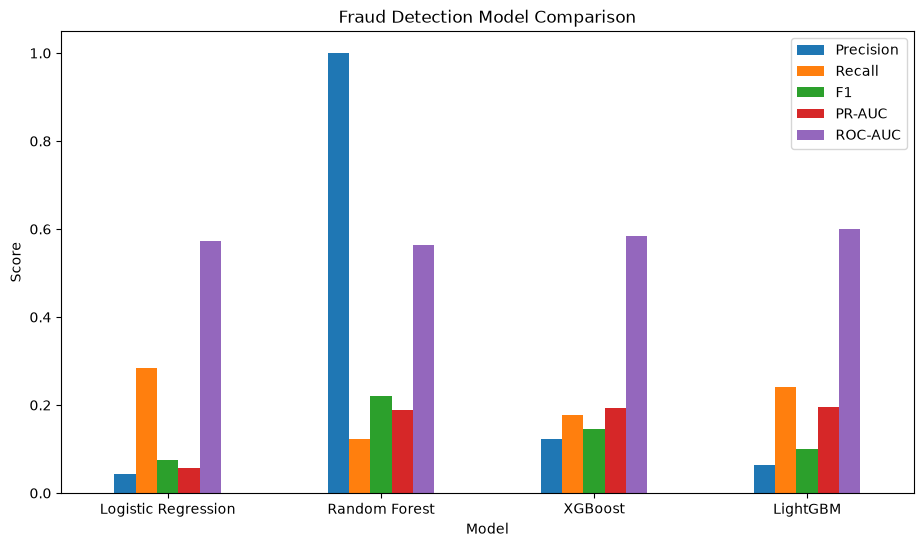

In [51]:
results_df.set_index('Model')[
    ['Precision', 'Recall', 'F1', 'PR-AUC', 'ROC-AUC']
].plot(kind='bar', figsize=(11, 6))
plt.title('Fraud Detection Model Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.show()

In [52]:
from sklearn.metrics import precision_recall_curve
precision, recall, thresholds = precision_recall_curve(y_test,lgb_prob)

In [53]:
f1_scores = (
    2 * precision[:-1] * recall[:-1] /
    (precision[:-1] + recall[:-1] + 1e-10)
)
best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]
print("Best Threshold:", round(best_threshold, 4))
print("Best Precision:", round(precision[best_index], 4))
print("Best Recall:", round(recall[best_index], 4))
print("Best F1:", round(f1_scores[best_index], 4))

Best Threshold: 0.8109
Best Precision: 0.8387
Best Recall: 0.1608
Best F1: 0.2699


In [54]:
lgb_pred_tuned = (lgb_prob >= best_threshold).astype(int)

In [55]:
print(classification_report(y_test,lgb_pred_tuned))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     19515
           1       0.84      0.16      0.27       485

    accuracy                           0.98     20000
   macro avg       0.91      0.58      0.63     20000
weighted avg       0.98      0.98      0.97     20000



In [57]:
tuned_cm = confusion_matrix(y_test,lgb_pred_tuned)
tuned_cm

array([[19500,    15],
       [  407,    78]])

In [58]:
tn, fp, fn, tp = tuned_cm.ravel()
tuned_fpr = fp / (fp + tn)
tuned_fnr = fn / (fn + tp)
print("FPR:", round(tuned_fpr, 4))
print("FNR:", round(tuned_fnr, 4))

FPR: 0.0008
FNR: 0.8392


In [59]:
threshold_results = []
for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    pred = (lgb_prob >= t).astype(int)
    threshold_results.append({
        'Threshold': t,
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred)
    })
pd.DataFrame(threshold_results).round(4)

,Threshold,Precision,Recall,F1
0,0.1,0.0244,0.9959,0.0476
1,0.2,0.0246,0.9753,0.0481
2,0.3,0.0253,0.9320,0.0493
3,0.4,0.0279,0.7031,0.0537
4,0.5,0.0629,0.2412,0.0998


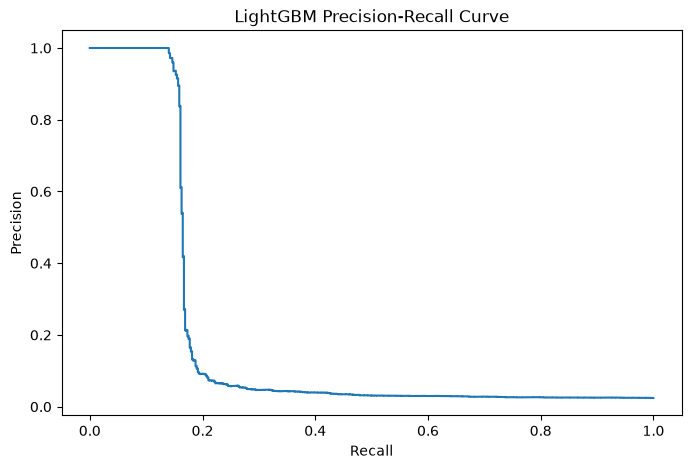

In [60]:
plt.figure(figsize=(8, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('LightGBM Precision-Recall Curve')
plt.show()

In [61]:
import joblib

In [62]:
joblib.dump(lgb_model,'lightgbm_fraud_model.pkl')
print("Model saved successfully.")

Model saved successfully.


In [63]:
model_info = {
    'model': 'LightGBM',
    'default_threshold': 0.5,
    'best_f1_threshold': round(best_threshold, 4),
    'pr_auc': round(lgb_pr, 4),
    'roc_auc': round(lgb_roc, 4)
}
model_info

{'model': 'LightGBM',
 'default_threshold': 0.5,
 'best_f1_threshold': np.float64(0.8109),
 'pr_auc': 0.1954,
 'roc_auc': 0.6}

## Isolation Forest

In [64]:
from sklearn.ensemble import IsolationForest

In [65]:
anomaly_features = [
    'amount',
    'transactions_last_24h',
    'avg_amount_30d',
    'failed_attempts',
    'distance_from_usual_location_km',
    'amount_to_avg_ratio',
    'risk_signal_count'
]
X_anomaly = df[anomaly_features]
X_anomaly.head()

,amount,transactions_last_24h,avg_amount_30d,failed_attempts,distance_from_usual_location_km,amount_to_avg_ratio,risk_signal_count
0,1152.81,6,590.31,2,16.1,1.952889,2
1,300.44,4,306.38,1,10.6,0.980612,1
2,1800.26,4,1371.06,0,0.6,1.313042,1
3,2177.21,5,799.99,1,15.5,2.721547,1
4,120.81,2,886.76,0,5.2,0.136238,1


In [66]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_anomaly_scaled = scaler.fit_transform(X_anomaly)

In [67]:
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.024,
    random_state=42
)
iso_model.fit(X_anomaly_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.024
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [68]:
iso_pred = iso_model.predict(X_anomaly_scaled)
df['anomaly_flag'] = (iso_pred == -1).astype(int)

In [69]:
df['anomaly_flag'].value_counts()

anomaly_flag
0    97600
1     2400
Name: count, dtype: int64

In [70]:
raw_score = -iso_model.decision_function(X_anomaly_scaled)
df['anomaly_score'] = raw_score

In [71]:
df[['anomaly_score', 'anomaly_flag']].head()

,anomaly_score,anomaly_flag
0,-0.070119,0
1,-0.188133,0
2,-0.189052,0
3,-0.168138,0
4,-0.184462,0


In [72]:
from sklearn.preprocessing import MinMaxScaler
score_scaler = MinMaxScaler(feature_range=(0, 100))
df['anomaly_score_100'] = score_scaler.fit_transform(df[['anomaly_score']])
df[['anomaly_score', 'anomaly_score_100']].head()

,anomaly_score,anomaly_score_100
0,-0.070119,40.923211
1,-0.188133,10.544912
2,-0.189052,10.308378
3,-0.168138,15.692003
4,-0.184462,11.490020


In [73]:
pd.crosstab(df['anomaly_flag'],df['fraud_label'])

fraud_label,0,1
anomaly_flag,,
0,95420,2180
1,2155,245


In [74]:
df.groupby('anomaly_flag')['fraud_label'].mean() * 100

anomaly_flag
0     2.233607
1    10.208333
Name: fraud_label, dtype: float64

In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score
print("Precision:",
      round(precision_score(df['fraud_label'], df['anomaly_flag']), 4))
print("Recall:",
      round(recall_score(df['fraud_label'], df['anomaly_flag']), 4))
print("F1:",
      round(f1_score(df['fraud_label'], df['anomaly_flag']), 4))

Precision: 0.1021
Recall: 0.101
F1: 0.1016


In [76]:
top_anomalies = df.sort_values('anomaly_score_100',ascending=False)
top_anomalies[
    [
        'transaction_id',
        'amount',
        'transactions_last_24h',
        'failed_attempts',
        'distance_from_usual_location_km',
        'amount_to_avg_ratio',
        'risk_signal_count',
        'anomaly_score_100',
        'fraud_label'
    ]
].head(20)

,transaction_id,amount,transactions_last_24h,failed_attempts,distance_from_usual_location_km,amount_to_avg_ratio,risk_signal_count,anomaly_score_100,fraud_label
9005,TXN0009006,13004.71,3,3,22.8,25.262165,4,100.000000,1
13834,TXN0013835,7013.12,8,2,50.9,21.111773,5,98.849257,0
32218,TXN0032219,27496.22,5,3,12.7,39.257881,2,98.007976,0
95398,TXN0095399,20234.17,9,1,2.2,86.533678,3,97.184253,0
80668,TXN0080669,35443.89,4,1,0.1,71.882636,3,96.816415,1
7404,TXN0007405,14040.47,7,0,35.7,87.142937,3,96.649775,1
77582,TXN0077583,28392.94,5,1,40.5,27.522940,3,96.439783,1
89709,TXN0089710,19404.44,4,2,8.0,46.496633,3,96.309097,1
33806,TXN0033807,50673.55,7,0,42.2,71.707516,2,95.694502,0
66820,TXN0066821,13041.12,11,0,26.1,45.695785,4,95.635064,0


In [77]:
import joblib
joblib.dump(
    iso_model,
    'isolation_forest_model.pkl'
)
joblib.dump(
    scaler,
    'anomaly_scaler.pkl'
)
joblib.dump(
    score_scaler,
    'anomaly_score_scaler.pkl'
)
print("Isolation Forest saved.")

Isolation Forest saved.


## Risk Score Engine

In [78]:
X_all = df.drop(
    columns=[
        'transaction_id',
        'timestamp',
        'fraud_label',
        'high_amount',
        'late_night',
        'anomaly_flag',
        'anomaly_score',
        'anomaly_score_100'
    ],
    errors='ignore'
)

In [79]:
df['fraud_probability'] = (lgb_model.predict_proba(X_all)[:, 1] * 100)
df[['fraud_probability']].head()

,fraud_probability
0,48.109653
1,41.849034
2,59.722619
3,35.529104
4,34.413587


In [80]:
df['behavior_score'] = (df['risk_signal_count'] / 5 * 100).clip(0, 100)

In [81]:
df[['risk_signal_count', 'behavior_score']].head()

,risk_signal_count,behavior_score
0,2,40.0
1,1,20.0
2,1,20.0
3,1,20.0
4,1,20.0


In [82]:
df['risk_score'] = (
    0.60 * df['fraud_probability'] +
    0.25 * df['anomaly_score_100'] +
    0.15 * df['behavior_score']
)

In [83]:
df['risk_score'] = df['risk_score'].round(2)

In [84]:
def risk_level(score):
    if score < 30:
        return 'LOW'
    elif score < 60:
        return 'MEDIUM'
    else:
        return 'HIGH'

In [85]:
df['risk_level'] = df['risk_score'].apply(risk_level)
df['risk_level'].value_counts()

risk_level
MEDIUM    51502
LOW       47729
HIGH        769
Name: count, dtype: int64

In [86]:
df.groupby('risk_level')['fraud_label'].agg(['count', 'sum', 'mean'])

,count,sum,mean
risk_level,,,
HIGH,769,474,0.616385
LOW,47729,415,0.008695
MEDIUM,51502,1536,0.029824


In [87]:
df.groupby('risk_level')['fraud_label'].mean() * 100

risk_level
HIGH      61.638492
LOW        0.869492
MEDIUM     2.982408
Name: fraud_label, dtype: float64

In [88]:
high_risk = df[df['risk_level'] == 'HIGH'].sort_values('risk_score',ascending=False)
high_risk[
    [
        'transaction_id',
        'amount',
        'fraud_probability',
        'anomaly_score_100',
        'risk_signal_count',
        'risk_score',
        'risk_level',
        'fraud_label'
    ]
].head(20)

,transaction_id,amount,fraud_probability,anomaly_score_100,risk_signal_count,risk_score,risk_level,fraud_label
9005,TXN0009006,13004.71,99.455645,100.000000,4,96.67,HIGH,1
54150,TXN0054151,13584.33,98.484315,93.321909,4,94.42,HIGH,1
96018,TXN0096019,14505.51,99.612335,89.819290,4,94.22,HIGH,1
57356,TXN0057357,10903.22,97.334342,94.698272,4,94.08,HIGH,1
39175,TXN0039176,4148.87,99.342489,82.603500,4,92.26,HIGH,1
7404,TXN0007405,14040.47,98.106416,96.649775,3,92.03,HIGH,1
67709,TXN0067710,11197.71,98.257065,84.244122,4,92.02,HIGH,1
87823,TXN0087824,14839.85,98.763087,94.945655,3,91.99,HIGH,1
80556,TXN0080557,2684.37,99.026309,70.122577,5,91.95,HIGH,1
77582,TXN0077583,28392.94,98.004812,96.439783,3,91.91,HIGH,1


In [89]:
def get_reasons(row):
    reasons = []

    if row['high_amount_flag'] == 1:
        reasons.append('Unusually high amount')

    if row['velocity_flag'] == 1:
        reasons.append('High transaction velocity')

    if row['location_anomaly_flag'] == 1:
        reasons.append('Unusual location')

    if row['new_device'] == 1:
        reasons.append('New device')

    if row['new_receiver'] == 1:
        reasons.append('New receiver')

    if row['failed_attempts'] >= 2:
        reasons.append('Multiple failed attempts')

    if row['late_night_flag'] == 1:
        reasons.append('Late-night transaction')

    return ', '.join(reasons) if reasons else 'No strong behavioral signal'

In [90]:
df['risk_reasons'] = df.apply(get_reasons,axis=1)

In [91]:
df[
    [
        'transaction_id',
        'fraud_probability',
        'anomaly_score_100',
        'risk_score',
        'risk_level',
        'risk_reasons'
    ]
].head(10)

,transaction_id,fraud_probability,anomaly_score_100,risk_score,risk_level,risk_reasons
0,TXN0000001,48.109653,40.923211,45.10,MEDIUM,"Multiple failed attempts, Late-night transaction"
1,TXN0000002,41.849034,10.544912,30.75,MEDIUM,Late-night transaction
2,TXN0000003,59.722619,10.308378,41.41,MEDIUM,Late-night transaction
3,TXN0000004,35.529104,15.692003,28.24,LOW,Late-night transaction
4,TXN0000005,34.413587,11.490020,26.52,LOW,Late-night transaction
5,TXN0000006,44.703989,24.613408,35.98,MEDIUM,Late-night transaction
6,TXN0000007,43.242974,0.974533,29.19,LOW,"New receiver, Late-night transaction"
7,TXN0000008,35.561889,13.281613,27.66,LOW,Late-night transaction
8,TXN0000009,42.524381,2.028781,29.02,LOW,Late-night transaction
9,TXN0000010,15.183405,26.701089,18.79,LOW,Late-night transaction


In [92]:
df.to_csv('upi_fraud_risk_scored.csv',index=False)
print("Risk scored dataset saved.")

Risk scored dataset saved.


## SHAP Explainability 

In [93]:
%pip install shap

   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/41.9 MB 2.2 MB/s eta 0:00:19
   - -------------------------------------- 1.3/41.9 MB 1.7 MB/s eta 0:00:25
   - -------------------------------------- 1.3/41.9 MB 1.7 MB/s eta 0:00:25
   - -------------------------------------- 1.3/41.9 MB 1.7 MB/s eta 0:00:25
   - -------------------------------------- 1.6/41.9 MB 1.1 MB/s eta 0:00:37
   - -------------------------------------- 1.6/41.9 MB 1.1 MB/s eta 0:00:37
   - -------------------------------------- 1.6/41.9 MB 1.1 MB/s eta 0:00:37
   - -------------------------------------- 1.8/41.9 MB 898.8 kB/s eta 0:00:45
   -- ------------------------------------- 2.4/41.9 MB 1.0 MB/s eta 0:00:38
   -- ------------------------------------- 2.9/41.9 MB 1.1 MB/s eta 0:00:36
   --- -----------

In [94]:
import shap
import matplotlib.pyplot as plt

In [95]:
preprocessor_fitted = lgb_model.named_steps['preprocessor']
lightgbm_fitted = lgb_model.named_steps['model']

In [96]:
X_shap = X_test.sample(n=2000,random_state=42)
X_shap_transformed = preprocessor_fitted.transform(X_shap)

In [97]:
feature_names = preprocessor_fitted.get_feature_names_out()
len(feature_names)

10031

In [98]:
explainer = shap.TreeExplainer(lightgbm_fitted)
shap_values = explainer.shap_values(X_shap_transformed)

c:\Users\iamga\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [99]:
if isinstance(shap_values, list):
    shap_values = shap_values[-1]

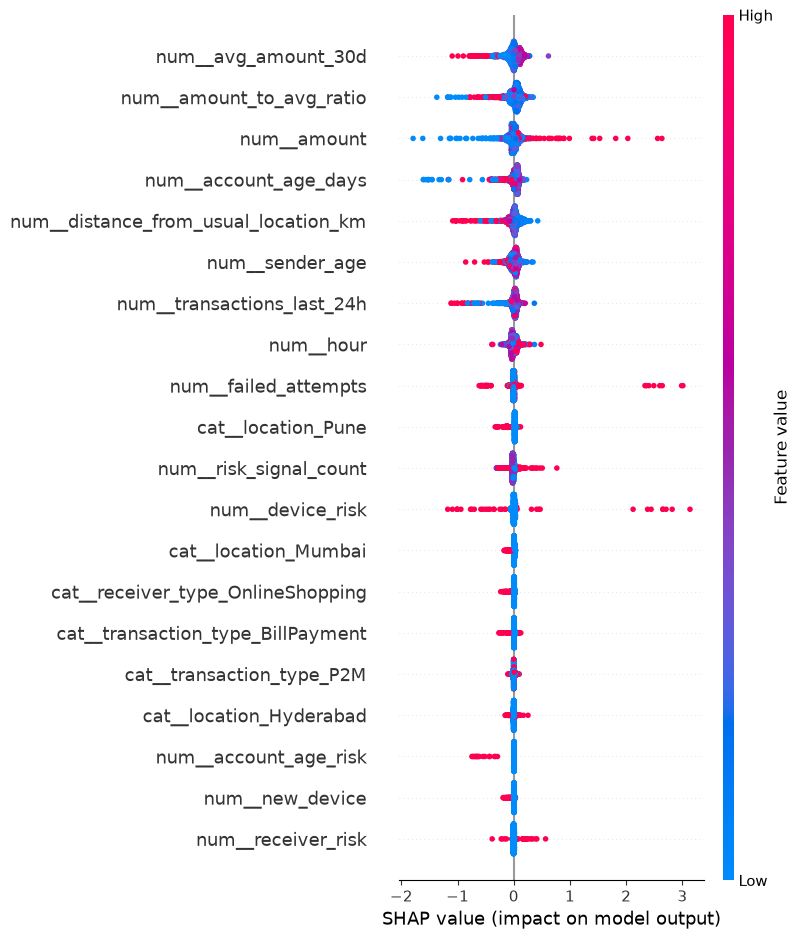

In [101]:
shap_values_plot = (
    shap_values.toarray()
    if hasattr(shap_values, "toarray")
    else shap_values
)

X_shap_plot = (
    X_shap_transformed.toarray()
    if hasattr(X_shap_transformed, "toarray")
    else X_shap_transformed
)

shap.summary_plot(
    shap_values_plot,
    X_shap_plot,
    feature_names=feature_names
)

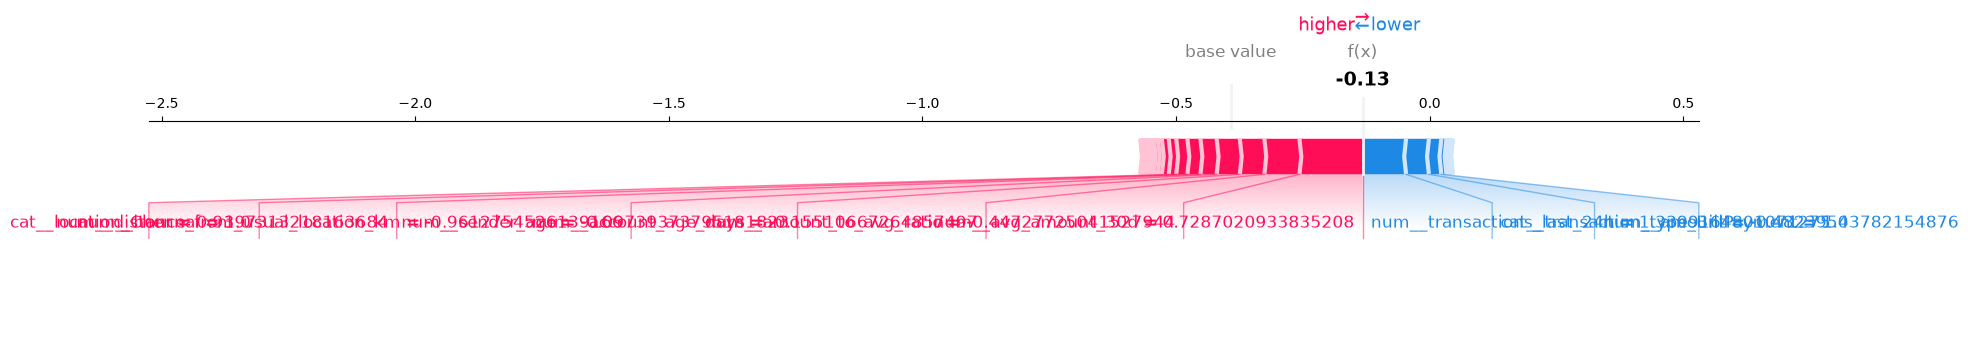

In [103]:
transaction_index = 0

base_value = explainer.expected_value
if hasattr(base_value, '__len__') and not isinstance(base_value, str):
    base_value = base_value[-1]

transaction_shap_values = shap_values[transaction_index].toarray().ravel()
transaction_data = X_shap_transformed[transaction_index].toarray().ravel()

transaction_explanation = shap.Explanation(
    values=transaction_shap_values,
    base_values=base_value,
    data=transaction_data,
    feature_names=feature_names
)

shap.plots.force(transaction_explanation, matplotlib=True)

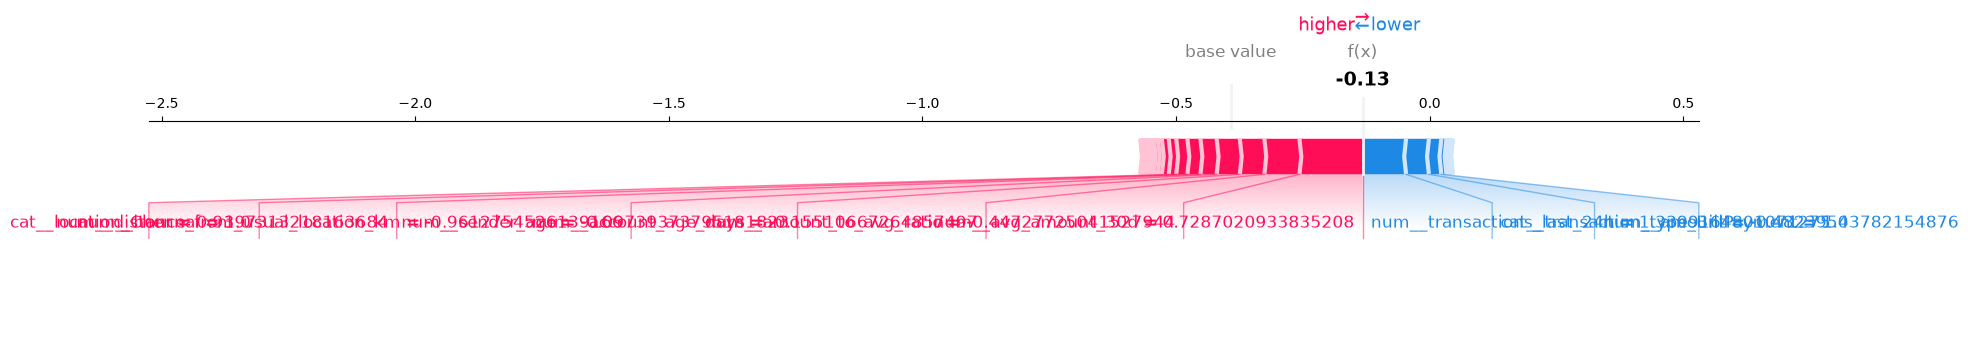

In [105]:
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = np.array(expected_value).flatten()[-1]

shap.force_plot(
    expected_value,
    transaction_shap_values,
    transaction_data,
    feature_names=feature_names,
    matplotlib=True
)

In [107]:
transaction_shap = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': transaction_shap_values
})
transaction_shap['Impact'] = transaction_shap['SHAP_Value'].abs()
transaction_shap.sort_values(
    'Impact',
    ascending=False
).head(10)

,Feature,SHAP_Value,Impact
5,num__avg_amount_30d,0.124587,0.124587
4,num__transactions_last_24h,-0.085645,0.085645
10,num__amount_to_avg_ratio,0.069126,0.069126
3,num__account_age_days,0.048385,0.048385
1,num__sender_age,0.045632,0.045632
24,cat__transaction_type_BillPayment,-0.045045,0.045045
9,num__distance_from_usual_location_km,0.031993,0.031993
2,num__hour,0.025716,0.025716
0,num__amount,-0.024457,0.024457
10025,cat__location_Chennai,0.021999,0.021999


In [108]:
high_idx = lgb_prob.argmax()

high_transaction = X_test.iloc[[high_idx]]

high_transformed = preprocessor_fitted.transform(
    high_transaction
)

high_shap = explainer.shap_values(
    high_transformed
)

if isinstance(high_shap, list):
    high_shap = high_shap[-1]

c:\Users\iamga\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


In [110]:
high_shap_values = (
    high_shap.toarray().ravel()
    if hasattr(high_shap, 'toarray')
    else np.asarray(high_shap).ravel()
)

high_explanation = pd.DataFrame({
    'Feature': feature_names,
    'SHAP_Value': high_shap_values
})

high_explanation['Impact'] = high_explanation['SHAP_Value'].abs()

high_explanation.sort_values(
    'Impact',
    ascending=False
).head(10)

,Feature,SHAP_Value,Impact
8,num__failed_attempts,1.850648,1.850648
14,num__device_risk,1.456895,1.456895
0,num__amount,1.441528,1.441528
6,num__new_receiver,0.422177,0.422177
15,num__receiver_risk,0.401814,0.401814
19,num__risk_signal_count,0.215785,0.215785
10,num__amount_to_avg_ratio,-0.145825,0.145825
7,num__new_device,0.123199,0.123199
3,num__account_age_days,0.103239,0.103239
2,num__hour,-0.064237,0.064237


## Fast API Backend

In [111]:
import os
print(os.getcwd())

c:\Users\iamga\Downloads\MY PROJECTS\upi\notebooks


In [112]:
import glob
glob.glob("*.pkl")

['anomaly_scaler.pkl',
 'anomaly_score_scaler.pkl',
 'isolation_forest_model.pkl',
 'lightgbm_fraud_model.pkl']